In [29]:
import sys
sys.path.insert(0, '../Modules/')
import numpy as np
import torch
from sklearn.decomposition import PCA
from index_set import index_set
#from index_set import bounded_hyperbolic_cross_set
from families import JacobiPolynomials
from HAlphaBasisCompressor import HAlphaBasisCompressor
from OperatorLearningPlotter import OperatorLearningPlotter
from Empirical_Operator_WLS import Empirical_Operator_WLS

### Dimension Reduction parameters
nPCA_Max =  750              # Maximum number of PCA modes allowed
PCA_Threshold = 0.995        # Amount of energy to retain in input space
alpha = 0                    # Sobolev Parameter for output space: 0 = L^2, 1 = H^1, etc.  
HAlpha_Threshold = 0.999     # Amount of energy to retain in output data

### Scale input data to lie in [-1,1]: 
normalization = 'uniform'    # Scale all input data uniformly, to maintain relative magnitudes

### Load data 
# Spatial data is on 128 x 128 grid
train_dat = torch.load('Spatial_Data/nsforcing_train_128.pt', weights_only=True)
test_dat  = torch.load('Spatial_Data/nsforcing_test_128.pt', weights_only=True )
X_train_grid = train_dat['x'].numpy()
Y_train_grid = train_dat['y'].numpy()
X_test_grid  = test_dat['x'].numpy()
Y_test_grid  = test_dat['y'].numpy()

# Reshape X grid data to vector for PCA
X_train = X_train_grid.reshape(X_train_grid.shape[0],-1)
X_test  = X_test_grid.reshape(X_test_grid.shape[0], -1) 

# Adaptively choose number of PCA coeffcients 
pca = PCA(n_components = nPCA_Max)
pca.fit(X_train)
nPCA_X = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), PCA_Threshold)+1

# Preform PCA to lower dimensionality
pca_X = PCA(n_components=nPCA_X)
input_data_raw = pca_X.fit_transform(X_train)
input_data_raw_test = pca_X.transform(X_test)

# Scale input coefficients to lie in [-1,1] for Jacobi Polynomial Domain 
if normalization == 'uniform':
    linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test))))
    input_data = input_data_raw / linf
    input_test = input_data_raw_test / linf

elif normalization == 'entrywise': 
    input_data = np.zeros_like(input_data_raw)
    input_test = np.zeros_like(input_data_raw_test)
    for col in range(nPCA_X):
        linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test)))[:,col])
        input_data[:,col] = input_data_raw[:,col]/linf
        input_test[:,col] = input_data_raw_test[:,col]/linf
else:
    raise ValueError("Normalization must be either 'uniform' for 'entrywise'")

# Project Y Data onto H^alpha subspace:
compressor = HAlphaBasisCompressor(N=Y_train_grid.shape[1], threshold=HAlpha_Threshold, alpha = alpha)
compressor.fit(Y_train_grid) 
output_data = np.array([compressor.project(snapshot) for snapshot in Y_train_grid])
output_test = np.array([compressor.project(snapshot) for snapshot in Y_test_grid])

### Fit Jacobi Parameters Defining Measure on Input Space by Matching Empirical Variance 
#   NOTE: For symmetric beta distribution, Var_a = 1/(2a + 3)
VarX = np.var(input_data, axis = 0)
VarX_safe = np.clip(VarX, 1e-10, None)  # avoid blow up for near zero variance
jParams = ((1/VarX) - 3)/2   


In [30]:
energies = [0.5,0.6,0.7,0.8,0.9]
rel_errs = []
rel_test_errs = []
Ns = []

for energy in energies: 
    # Define polynomial part of index set
    H0_sorted_index_set = np.load("Data/H0_sorted_index_set.npy")
    retained_energy = np.load("Data/retained_energy_idx_set.npy")
    k = np.argmax(retained_energy[retained_energy < energy])
    idx_set = H0_sorted_index_set[:k,:]
    N = idx_set.shape[0]
    M = int(N*np.log(N))

    # Fit Operator to Training Data 
    wls_operator = Empirical_Operator_WLS(
        input_data = input_data, 
        output_data = output_data, 
        index_set = idx_set, 
        jacobi_params = jParams, 
        induced = True) 
    wls_operator.fit(M)

    # Evaluate Operator on Training Data
    ApproxOpSamp = wls_operator.predict_on_fit_samples()
    err, rel_err = wls_operator.compute_fit_sample_errors()

    # Evaluate Operator on Testing Data
    ApproxOpTest = wls_operator.predict(input_test)
    test_err, rel_test_err = wls_operator.compute_errors(input_test, output_test)

    rel_errs.append(np.mean(rel_err))
    rel_test_errs.append(np.mean(rel_test_err))
    Ns.append(N)

np.save('Data/energies.npy', energies)
np.save('Data/rel_errs_eng_thresh.npy', rel_errs)
np.save('Data/rel_test_errs_energy_thresh.npy', rel_test_errs)
np.save('Data/Ns_energy_thresh.npy', Ns)


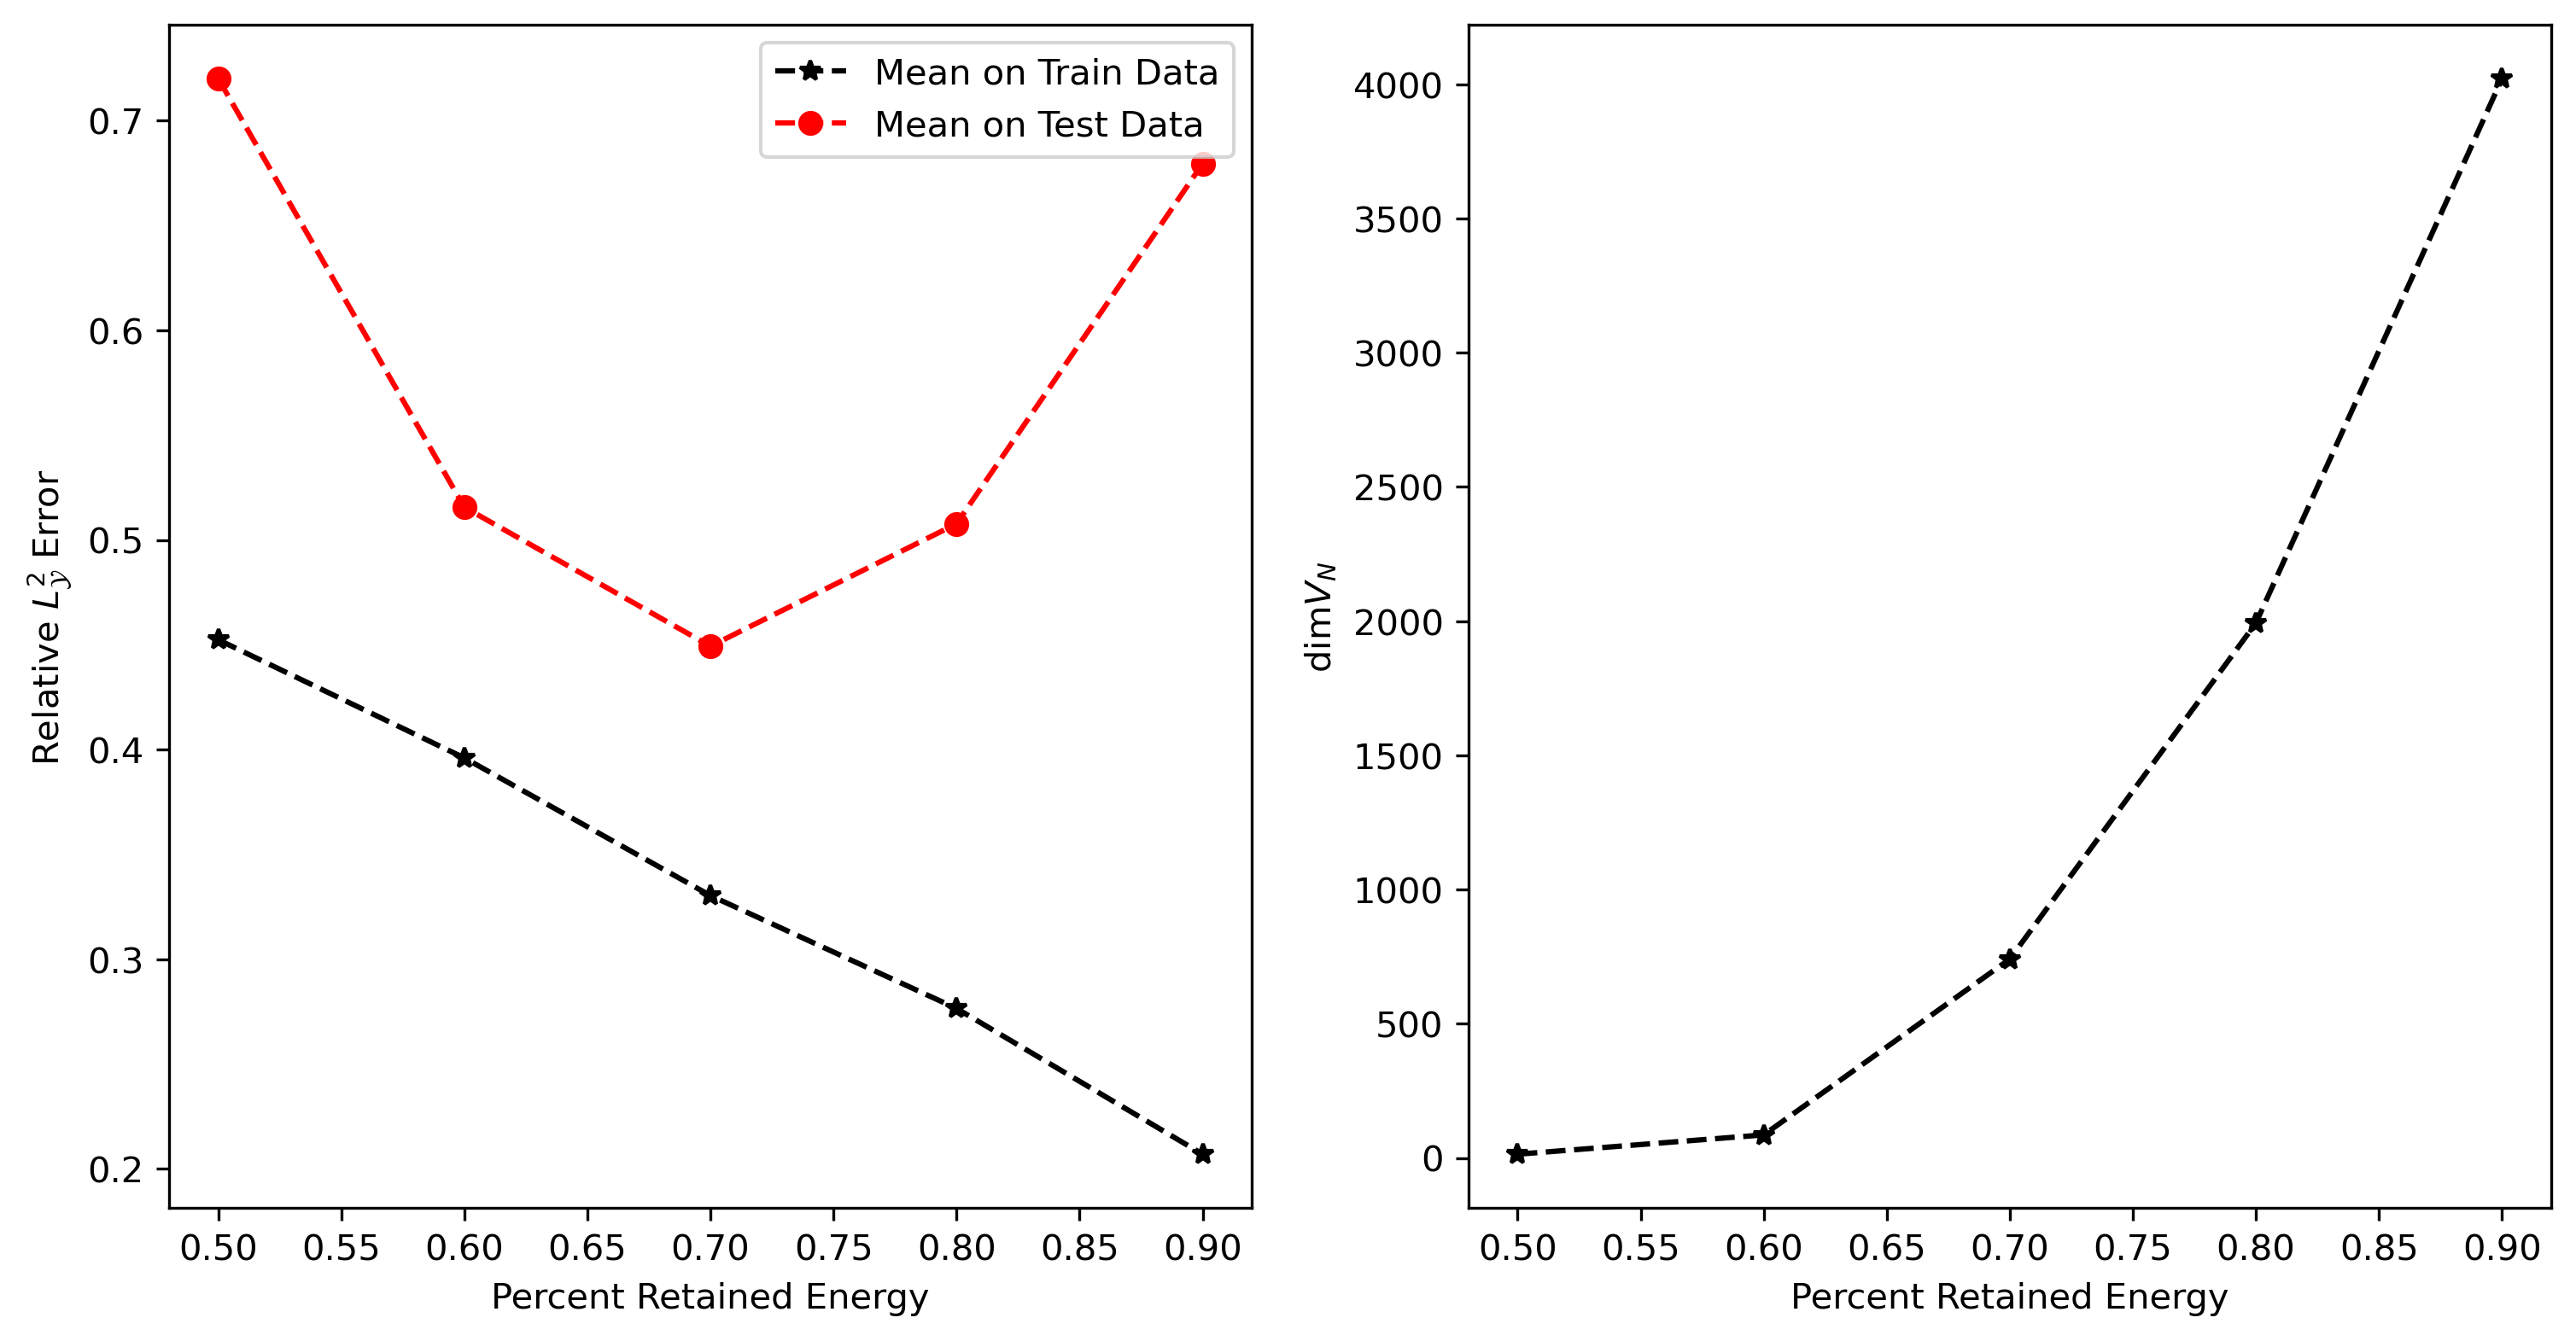

In [31]:
energies = np.load('Data/energies.npy')
rel_errs = np.load('Data/rel_errs_eng_thresh.npy')
rel_test_errs = np.load('Data/rel_test_errs_energy_thresh.npy')
Ns = np.load('Data/Ns_energy_thresh.npy')

import matplotlib.pyplot as plt 
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

fig,ax = plt.subplots(ncols = 2, figsize = (12,6))
ax[0].plot(energies, rel_errs, "*--", color = 'black', label = r'Mean on Train Data')
ax[0].plot(energies, rel_test_errs, "o--", color = 'red', label = r'Mean on Test Data' )
ax[0].set(xlabel = "Percent Retained Energy", ylabel = r"Relative $L^2_{\mathcal{Y}}$ Error")
ax[0].legend(loc = 'best')

ax[1].plot(energies, Ns, "*--", color = 'black')
ax[1].set(xlabel = "Percent Retained Energy", ylabel = r"$\mathrm{dim}V_N$")
plt.savefig("Plots/err_v_energy_thresh")
plt.show()